In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1.What is the overall on-time performance, and what do the overall distribution of adherence look like?

In [3]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [4]:
wego.isnull().sum()

CALENDAR_ID                       0
SERVICE_ABBR                      0
ADHERENCE_ID                      0
DATE                              0
ROUTE_ABBR                        0
BLOCK_ABBR                        0
OPERATOR                          0
TRIP_ID                           0
OVERLOAD_ID                       0
ROUTE_DIRECTION_NAME              0
TIME_POINT_ABBR                   0
ROUTE_STOP_SEQUENCE              11
TRIP_EDGE                         0
LATITUDE                          0
LONGITUDE                         0
SCHEDULED_TIME                    0
ACTUAL_ARRIVAL_TIME           11459
ACTUAL_DEPARTURE_TIME         11468
ADHERENCE                     11468
SCHEDULED_HDWY                75591
ACTUAL_HDWY                   84267
HDWY_DEV                      84436
ADJUSTED_EARLY_COUNT              0
ADJUSTED_LATE_COUNT               0
ADJUSTED_ONTIME_COUNT             0
STOP_CANCELLED                    0
PREV_SCHED_STOP_CANCELLED     70329
IS_RELIEF                   

In [5]:
wego_clean = wego.dropna(subset=['ADHERENCE', 'ACTUAL_DEPARTURE_TIME', 'SCHEDULED_TIME'])

In [6]:
wego_clean['SCHEDULED_TIME'] = pd.to_datetime(wego_clean['SCHEDULED_TIME'])
wego_clean['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(wego_clean['ACTUAL_DEPARTURE_TIME'])

C:\Users\user\AppData\Local\Temp\ipykernel_13740\3031627012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_clean['SCHEDULED_TIME'] = pd.to_datetime(wego_clean['SCHEDULED_TIME'])
C:\Users\user\AppData\Local\Temp\ipykernel_13740\3031627012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_clean['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(wego_clean['ACTUAL_DEPARTURE_TIME'])


In [7]:
wego_clean['ADHERENCE'] = pd.to_numeric(wego_clean['ADHERENCE'], errors='coerce')

C:\Users\user\AppData\Local\Temp\ipykernel_13740\3803004110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_clean['ADHERENCE'] = pd.to_numeric(wego_clean['ADHERENCE'], errors='coerce')


In [8]:
wego_clean = wego_clean.dropna(subset=['ADHERENCE'])

In [9]:
wego_clean.reset_index(drop=True, inplace=True)

In [10]:
wego_clean

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338856,120230930,2,100406610,2023-09-30,7,702,2312,353448,0,TO DOWNTOWN,...,35.266666,5.266666,0,1,0,0,0.0,0,0.000000,NaN
338857,120230930,2,100406611,2023-09-30,7,702,2312,353448,0,TO DOWNTOWN,...,NaN,NaN,0,1,0,0,NaN,0,0.000000,NaN
338858,120230930,2,100406612,2023-09-30,7,702,2312,353449,0,FROM DOWNTOWN,...,31.866666,1.866666,0,0,1,0,0.0,0,0.000000,NaN
338859,120230930,2,100406613,2023-09-30,7,702,2312,353449,0,FROM DOWNTOWN,...,47.500000,17.500000,0,1,0,0,0.0,0,0.000000,NaN


In [11]:
on_time = wego_clean[(wego_clean['ADHERENCE'] >= -6) & (wego_clean['ADHERENCE'] <= 1)].shape[0]
on_time

246791

In [12]:
late = wego_clean[wego_clean['ADHERENCE'] < -6].shape[0]
late

59038

In [13]:
early = wego_clean[wego_clean['ADHERENCE'] > 1].shape[0]
early

33032

In [14]:
total = on_time + late + early
total

338861

In [15]:
pct_on_time = round((on_time / total) * 100, 2)
pct_on_time

72.83

In [16]:
pct_late = round((late / total) * 100, 2)
pct_late

17.42

In [17]:
pct_early = round((early / total) * 100, 2)
pct_early

9.75

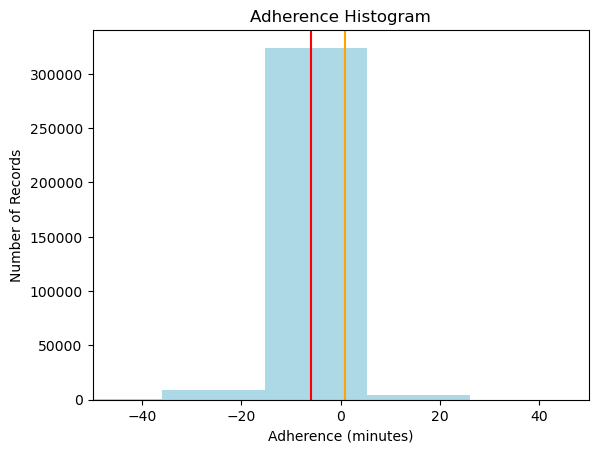

In [18]:
plt.hist(wego_clean['ADHERENCE'], bins=50, color='lightblue')
plt.title("Adherence Histogram")
plt.xlabel("Adherence (minutes)")
plt.ylabel("Number of Records")
plt.axvline(-6, color='red')   
plt.axvline(1, color='orange')  
plt.xlim(-50, 50)  
plt.show()

2. How does direction of travel, route, or location affect the on-time performance?

In [20]:
wego_clean.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In [21]:
def classify_adherence(adherence):
    if -6 <= adherence <= 1:
        return "On time"
    elif adherence < -6:
        return "Late"
    else:
        return "Early"

wego_clean['STATUS'] = wego_clean['ADHERENCE'].apply(classify_adherence)

In [22]:
direction_summary = wego_clean.groupby(['ROUTE_DIRECTION_NAME', 'STATUS']).size().unstack(fill_value=0)

direction_summary['Total'] = direction_summary.sum(axis=1)
direction_summary['% On time'] = round((direction_summary['On time'] / direction_summary['Total']) * 100, 2)

direction_summary

STATUS,Early,Late,On time,Total,% On time
ROUTE_DIRECTION_NAME,,,,,
FROM DOWNTOWN,13989,39601,125716,179306,70.11
TO DOWNTOWN,19043,19437,121075,159555,75.88


In [23]:
route_summary = wego_clean.groupby(['ROUTE_ABBR', 'STATUS']).size().unstack(fill_value=0)

route_summary['Total'] = route_summary.sum(axis=1)
route_summary['% On time'] = round((route_summary['On time'] / route_summary['Total']) * 100, 2)

route_summary_sorted = route_summary.sort_values(by='% On time', ascending=False)

route_summary_sorted.head(10)

STATUS,Early,Late,On time,Total,% On time
ROUTE_ABBR,,,,,
50,4106,5113,33410,42629,78.37
23,5621,3230,30802,39653,77.68
56,5920,8837,44193,58950,74.97
52,3549,10038,35740,49327,72.46
3,3185,9590,32713,45488,71.92
22,5075,2065,18048,25188,71.65
7,1782,3417,12068,17267,69.89
55,3794,16748,39817,60359,65.97


In [24]:
location_summary = wego_clean.groupby(['TIME_POINT_ABBR', 'STATUS']).size().unstack(fill_value=0)

location_summary['Total'] = location_summary.sum(axis=1)
location_summary['% On time'] = round((location_summary['On time'] / location_summary['Total']) * 100, 2)


location_summary_sorted = location_summary.sort_values(by='% On time')

location_summary_sorted.head(10)

STATUS,Early,Late,On time,Total,% On time
TIME_POINT_ABBR,,,,,
MCC5_7,3,31,2,36,5.56
MCC5_11,13,49,8,70,11.43
MCC5_6,100,1,15,116,12.93
MCC4_13,48,3,19,70,27.14
MCC5_12,3,23,13,39,33.33
MCC5_2,62,9,37,108,34.26
MCC4_20,21,43,35,99,35.35
HEAD,32,3,37,72,51.39
MCC4_22,15,34,53,102,51.96


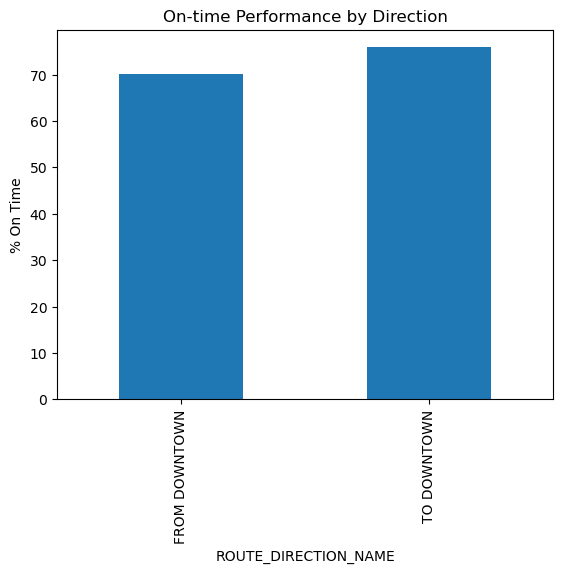

In [25]:
direction_summary['% On time'].plot(kind='bar', title='On-time Performance by Direction')
plt.ylabel('% On Time')
plt.show()

3.How does time of day or day of week affect on-time performance? 

In [27]:
wego_clean['DayOfWeek'] = wego_clean['SCHEDULED_TIME'].dt.day_name()
wego_clean['Hour'] = wego_clean['SCHEDULED_TIME'].dt.hour

In [28]:
day_summary = wego_clean.groupby(['DayOfWeek', 'STATUS']).size().unstack(fill_value=0)


day_summary['Total'] = day_summary.sum(axis=1)
day_summary['% On time'] = round((day_summary['On time'] / day_summary['Total']) * 100, 2)


ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_summary = day_summary.reindex(ordered_days)

day_summary

STATUS,Early,Late,On time,Total,% On time
DayOfWeek,,,,,
Monday,5309,5989,36146,47444,76.19
Tuesday,5420,9577,41640,56637,73.52
Wednesday,5361,10306,41260,56927,72.48
Thursday,5286,10642,40347,56275,71.70
Friday,5023,12107,38790,55920,69.37
Saturday,3282,6698,26506,36486,72.65
Sunday,3351,3719,22102,29172,75.76


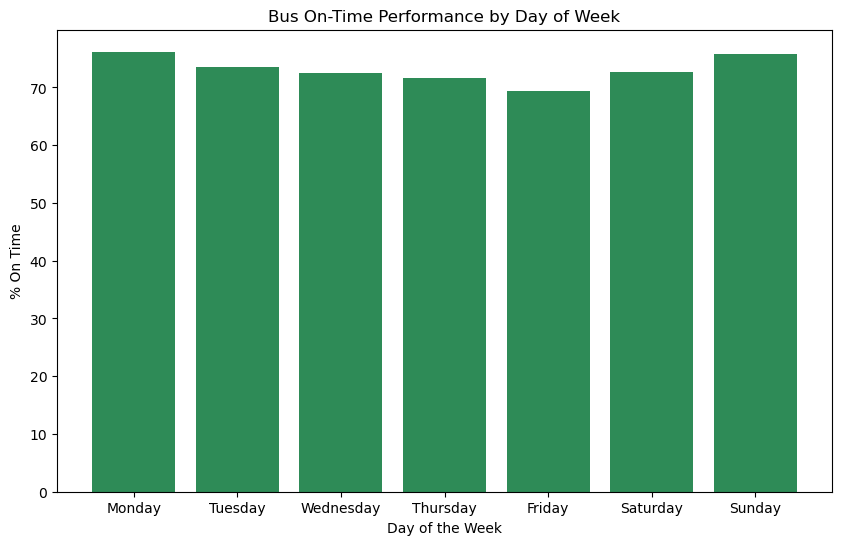

In [101]:
plt.figure(figsize=(10, 6))
plt.bar(day_summary.index, day_summary['% On time'], color='seagreen')
plt.xlabel('Day of the Week')
plt.ylabel('% On Time')
plt.title('Bus On-Time Performance by Day of Week')
plt.savefig('bus_on_time.png')
plt.show()

4.How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

In [32]:
wego_clean['OPERATOR'].nunique()

341

In [33]:
operator_summary = wego_clean.groupby(['OPERATOR', 'STATUS']).size().unstack(fill_value=0)

In [34]:
operator_summary['Total'] = operator_summary.sum(axis=1)
operator_summary['% On time'] = round((operator_summary['On time'] / operator_summary['Total']) * 100, 2)

In [35]:
operator_filtered = operator_summary[operator_summary['Total'] >= 50]

In [103]:
best_drivers = operator_filtered.sort_values(by='% On time', ascending=False).head(10)
worst_drivers = operator_filtered.sort_values(by='% On time', ascending=True).head(10)

worst_drivers

STATUS,Early,Late,On time,Total,% On time
OPERATOR,,,,,
1377,0,48,12,60,20.00
1016,5,87,46,138,33.33
2400,16,70,44,130,33.85
3098,16,251,190,457,41.58
3096,50,534,418,1002,41.72
3101,36,699,562,1297,43.33
3120,65,319,303,687,44.10
2312,18,714,580,1312,44.21
1904,42,461,403,906,44.48


In [37]:
operator_filtered = operator_summary[operator_summary['Total'] >= 50]
operator_filtered = operator_filtered.sort_values(by='% On time', ascending=False)

In [38]:
top_drivers = operator_filtered.head(10)
bottom_drivers = operator_filtered.tail(10)


In [39]:
selected_drivers = pd.concat([top_drivers, bottom_drivers])

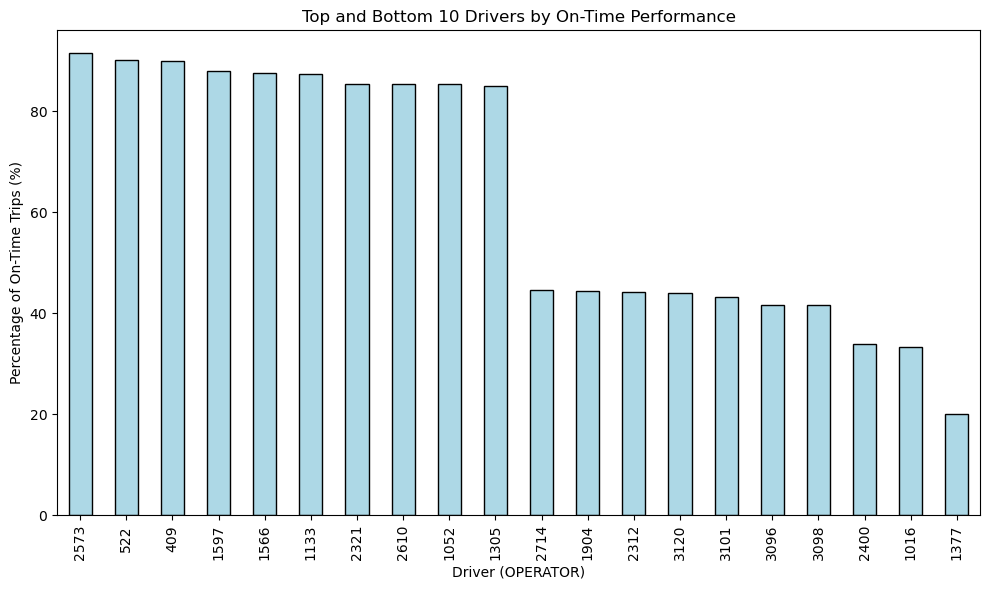

In [40]:
plt.figure(figsize=(10, 6))
selected_drivers['% On time'].plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Top and Bottom 10 Drivers by On-Time Performance")
plt.xlabel("Driver (OPERATOR)")
plt.ylabel("Percentage of On-Time Trips (%)")
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.show()

5.Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

In [42]:
wego_clean['ADHERENCE'] = pd.to_numeric(wego_clean['ADHERENCE'], errors='coerce')
wego_clean['HDWY_DEV'] = pd.to_numeric(wego_clean['HDWY_DEV'], errors='coerce')

In [43]:
wego_clean_cleaned = wego_clean.dropna(subset=['ADHERENCE', 'HDWY_DEV'])

In [44]:
correlation = wego_clean_cleaned[['ADHERENCE', 'HDWY_DEV']].corr()
print(f"Correlation between ADHERENCE and HDWY_DEV: {correlation.iloc[0, 1]}")

Correlation between ADHERENCE and HDWY_DEV: -0.20679390015313484


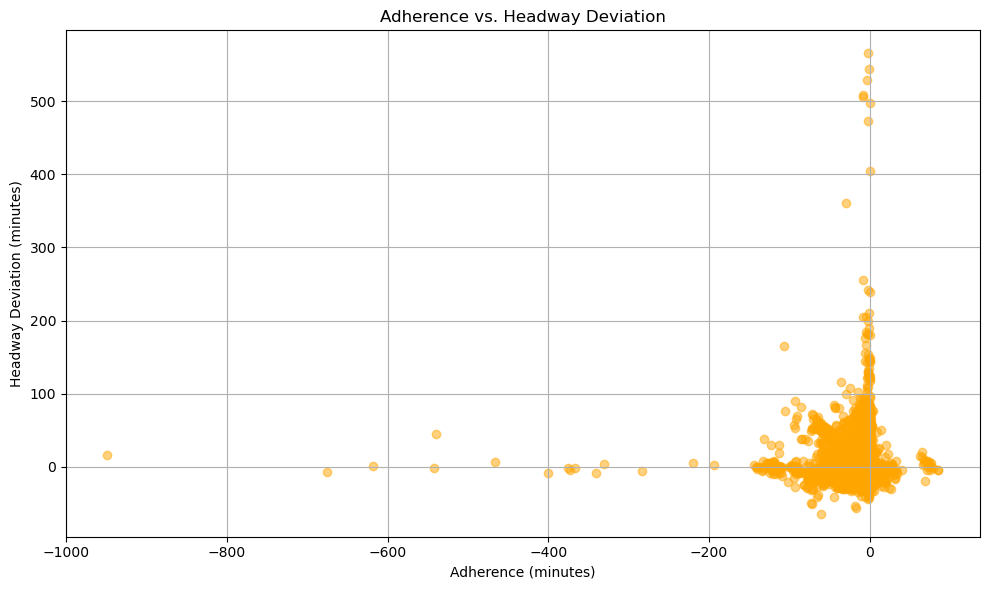

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(wego_clean_cleaned['ADHERENCE'], wego_clean_cleaned['HDWY_DEV'], color='orange', alpha=0.5)
plt.title("Adherence vs. Headway Deviation")
plt.xlabel("Adherence (minutes)")
plt.ylabel("Headway Deviation (minutes)")
plt.grid(True)
plt.tight_layout()
plt.savefig("adherence_vs_headway.png", dpi=300)
plt.show()